# Efficient Market State and Rough Volatility Detection Using the Grunwald-Letnikov Fractional Derivative

In statistics, the Kolmogorov-Smirnov (KS) statistic is used to derive the maximum distance between two cumulative distribution functions (CDFs). In quantitative finance, this is used to determine if a dataset has changed significantly compared to its past, modelling the risk of a particular stock given its history. The KS statistic assumes that the data points are independent and identically distributed (IID).

However, the KS statistic loses this independence assumption once the Hurst parameter, H, exceeds 0.5. Conceptually, this marks a shift between short-term memory and long-range dependence. When observing the KS statistic at a longer range, the process begins to exhibit long range positive autocorrelation. This clusters sequential observations of this process, making each progressive step carry less independent information and thus makes the process more deterministic. Stocks are not deterministic in nature, so using the KS statistic with a long-range dependence would no longer model the risk of the stock adequately.

However, a paper proposed by Daniele Angelini ('(In)Efficient Market States and Rough Volatility Detected via Grunwald-Letnikov Fractional Derivative' [https://arxiv.org/pdf/2606.27932]) suggests a new framework. Instead of relying on just the KS statistic, Angelini developed a KS/GL-KS framework based on the Grunwald-Letnikov (GL) fractional derivative to effectively filter out the long-range noise and preserve the H-self-similarity needed to identify distributions.

This notebook explores this concept and models how the KS/GL-KS framework is more effective at modelling risk for stocks with long range dependencies, aiding quants with efficient market state and rough volatility detection.

In [10]:
%pip install hurst

Defaulting to user installation because normal site-packages is not writeable
  Using cached hurst-0.0.5-py3-none-any.whl.metadata (3.6 kB)
Using cached hurst-0.0.5-py3-none-any.whl (5.9 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
# Install needed dependencies
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime
from matplotlib import pyplot as plt
from hurst import compute_Hc # Package to determine H

Our first step in visualizing this phenomenon is to derive the Hurst exponent, H. H determines if our stock has short-range dependencies (SRD) or long-range dependencies (LRD).

In [16]:
# We will use NVIDIA to show this phenomenon since it has strong price momentum
start_date = datetime(2020,1,1)
end_date = datetime(2021,1,31)
ticker = "TSLA"
interval = "1d"

price = yf.download(tickers=ticker, start=start_date, end=end_date, 
                    interval=interval, multi_level_index=False, auto_adjust=False)

price.head()

[*********************100%***********************]  1 of 1 completed


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2020-01-02,28.684000,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,32.809334,33.232666,31.215334,31.580000,467164500


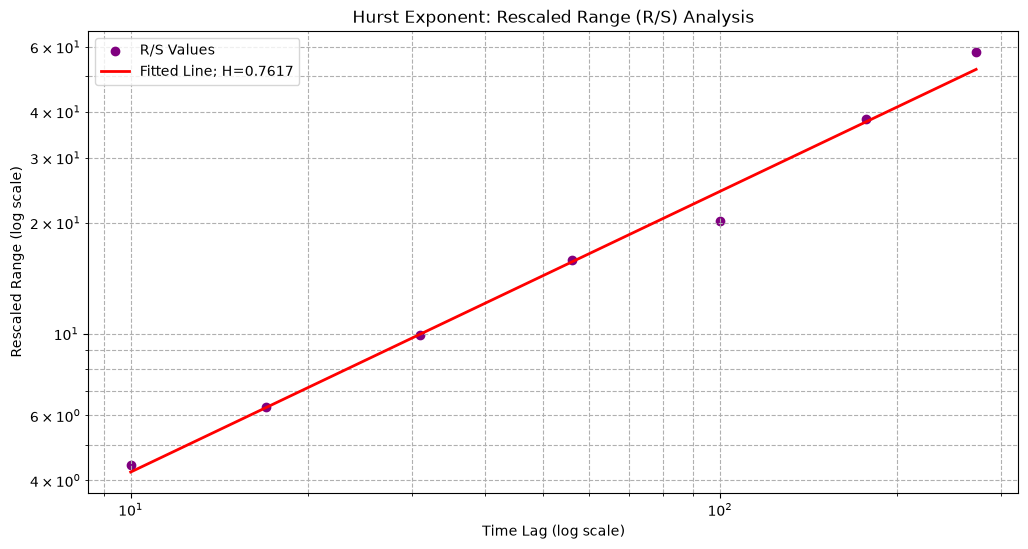

In [19]:
# Determine H from our log Adjusted Close prices
log_adj_close = np.log(price['Adj Close'].values.flatten())
H, c, data_points = compute_Hc(log_adj_close, kind='price', simplified=True)

lags = data_points[0]
rs = data_points[1]

fig, ax = plt.subplots(figsize=[12,6])
ax.scatter(lags, rs, color='purple', label='R/S Values')
ax.plot(lags, c * lags ** H, color='red', linewidth=2, label=f"Fitted Line; H={H:.4f}")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Time Lag (log scale)')
ax.set_ylabel('Rescaled Range (log scale)')
ax.set_title('Hurst Exponent: Rescaled Range (R/S) Analysis')

ax.legend()
plt.grid(True, which="both", ls="--")
plt.show()

Since our Hurst exponent is larger than 0.5, it has LRD. This occurs in stocks that have a very strong price momentum, have strong directional trends, and are less liquid. Tesla during the calendar year of 2020 would perfectly exemplify the phenomenon. 

Now, we will try to run a normal KS test on this stock over this particular timeframe. It will break because a larger Hurst parameter breaks the independence assumption within the KS test in two places:
- Interdependence problem arises from the statistical overlap among extracted rescaled series
- Intradependence problem arises from the internal autocorrelation governed by self-similarity of H

However, introducing a GL fractional derivative to this situation makes the spatial density of the process to behave asymptotically. Ultimately, the GL fractional derivative shifts the process out of LRD into a short memory, antipersistant structure, allowing us to effectively "filter out" the low-frequency noise caused by the LRD.

# Sources
Paper: https://arxiv.org/pdf/2606.27932

Hurst Documentation: https://pypi.org/project/hurst/